In [58]:
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import pydot
import seaborn as sns

#Evaluation library
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

# Deep Learning libraries
import tensorflow as tf
from tensorflow.keras import layers
import keras
from keras.models import Sequential
from keras.layers import Dense,Activation,Dropout
from keras.datasets import mnist
from keras.utils import to_categorical
from scikeras.wrappers import KerasClassifier


### MNIST Dataset

In [59]:
# Digit MNIST dataset
(X_train_digit, y_train_digit), (X_test_digit, y_test_digit) = mnist.load_data()
X_train_digit


array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [60]:
y_train_digit


array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

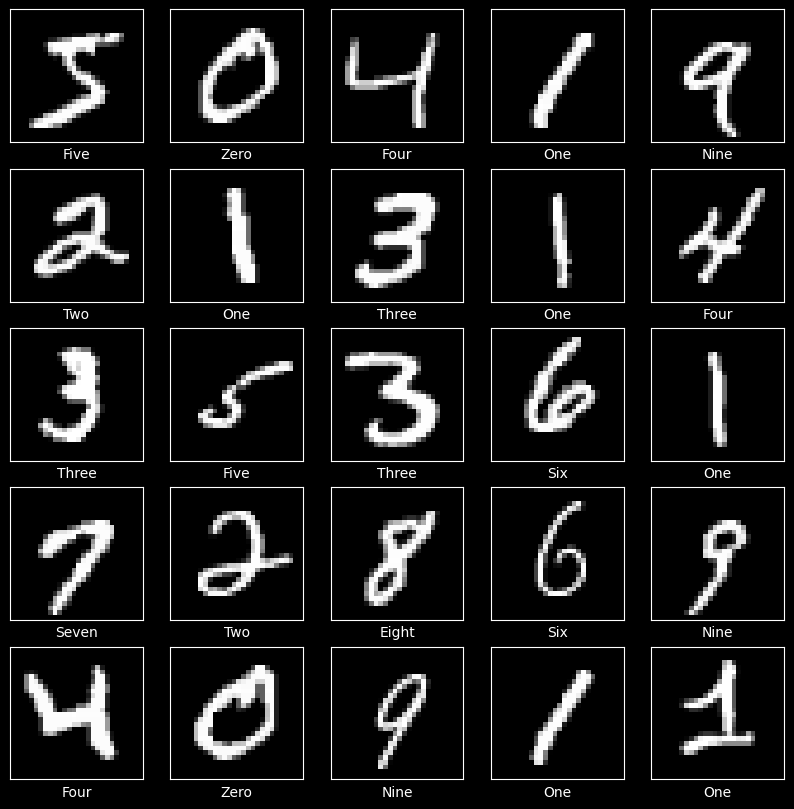

In [61]:
#Names of numbers in the dataset in order
col_names = ['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']

#Visualizing the digits
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train_digit[i], cmap='gray')
    plt.xlabel(col_names[y_train_digit[i]])
plt.show()


### Preprocessing input - converting 3D to 2D

In [62]:
print(X_train_digit.shape, X_test_digit.shape)


(60000, 28, 28) (10000, 28, 28)


In [63]:
X_train_digit = X_train_digit.reshape(60000, 784)
X_test_digit = X_test_digit.reshape(10000, 784)


### Preprocessing output - converting to one hot categorical data (1D to 2D)

In [64]:
print(y_train_digit.shape, y_test_digit.shape)


(60000,) (10000,)


In [65]:
y_train_digit = to_categorical(y_train_digit, num_classes=10)
y_test_digit = to_categorical(y_test_digit, num_classes=10)
y_train_digit


array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(60000, 10))

In [67]:
y_train_digit[3]


array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])

### Model creation

In [83]:
#Creating base neural network
model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    #layers.Dropout(0.3),   # decreases accurace by 0.3 to make learning better again.
    #layers.BatchNormalization(),     # normalize data for next layer
    layers.Dense(64, activation='relu'),
    #layers.Dropout(0.3),
    #layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    # layers.Dropout(0.3),
    #layers.BatchNormalization(),
    layers.Dense(10,activation='sigmoid'),
])


In [84]:
# Parameters=input units × (output units + 1)
model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,218 (868.04 KB)

 Trainable params: 222,218 (868.04 KB)

 Non-trainable params: 0 (0.00 B)

### Compiling the Model

In [85]:
# https://keras.io/api/losses/probabilistic_losses/#sparsecategoricalcrossentropy-class
#Compiling the model
model.compile(loss="categorical_crossentropy",
              optimizer="adam",
              metrics = ['accuracy'])


In [86]:
history=model.fit(X_train_digit, y_train_digit, batch_size=100, epochs=10,validation_data=(X_test_digit, y_test_digit))


Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8012 - loss: 1.5833 - val_accuracy: 0.8585 - val_loss: 0.3146
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8917 - loss: 0.2551 - val_accuracy: 0.9141 - val_loss: 0.2135
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9079 - loss: 0.1736 - val_accuracy: 0.8924 - val_loss: 0.1799
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9206 - loss: 0.1321 - val_accuracy: 0.8916 - val_loss: 0.1796
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9061 - loss: 0.1186 - val_accuracy: 0.8794 - val_loss: 0.1694
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9091 - loss: 0.0983 - val_accuracy: 0.9021 - val_loss: 0.1523
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9127 - loss: 0.0944 - val_accuracy: 0.9090 - val_loss: 0.1327
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9010 - loss: 0.0839 - val_accuracy: 0.

### Predicting 

In [87]:
#Predicting the labels-DIGIT
y_predict = model.predict(X_test_digit)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [ ]:
y_predict[0]


array([1.6159166e-03, 3.6278695e-03, 6.7704660e-01, 2.6200831e-01,
       5.8180178e-03, 2.2003299e-03, 3.8351953e-09, 1.0000000e+00,
       9.5779070e-04, 1.2516474e-02], dtype=float32)

In [ ]:
# Predicted values reverse encoding
y_predicts=np.argmax(y_predict, axis=1) # Here we get the index of maximum value in the encoded vector
y_predicts


array([7, 1, 1, ..., 4, 5, 6], shape=(10000,))

In [91]:
y_predicts[0]


np.int64(7)

In [ ]:
# Test values reverse encoding
y_test_digit_eval=np.argmax(y_test_digit, axis=1)
y_test_digit_eval


array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

### Visualising the Confusion Matrix using Heatmap

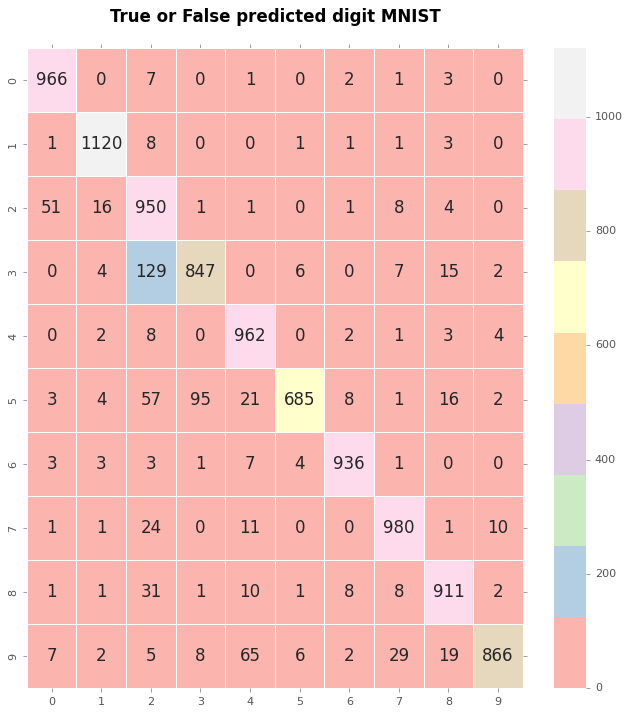

In [99]:
#Confusion matrix for Digit MNIST
con_mat=confusion_matrix(y_test_digit_eval,y_predicts)
plt.style.use('ggplot')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True,annot_kws={'size': 15},linewidths=0.5,fmt="d",cmap="Pastel1")
plt.title('True or False predicted digit MNIST\n',fontweight='bold',fontsize=15)
plt.show()


### Classification Report

In [100]:
from sklearn.metrics import classification_report

print(classification_report(y_test_digit_eval,y_predicts))


              precision    recall  f1-score   support

           0       0.94      0.99      0.96       980
           1       0.97      0.99      0.98      1135
           2       0.78      0.92      0.84      1032
           3       0.89      0.84      0.86      1010
           4       0.89      0.98      0.93       982
           5       0.97      0.77      0.86       892
           6       0.97      0.98      0.98       958
           7       0.95      0.95      0.95      1028
           8       0.93      0.94      0.93       974
           9       0.98      0.86      0.91      1009

    accuracy                           0.92     10000
   macro avg       0.93      0.92      0.92     10000
weighted avg       0.93      0.92      0.92     10000



### Accuracy Plot

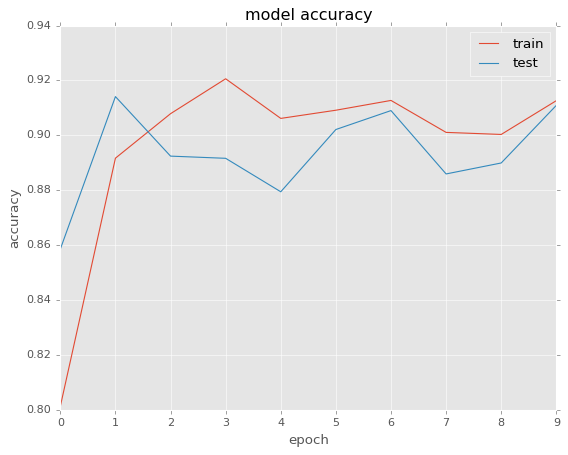

In [102]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()


### Loss Plot

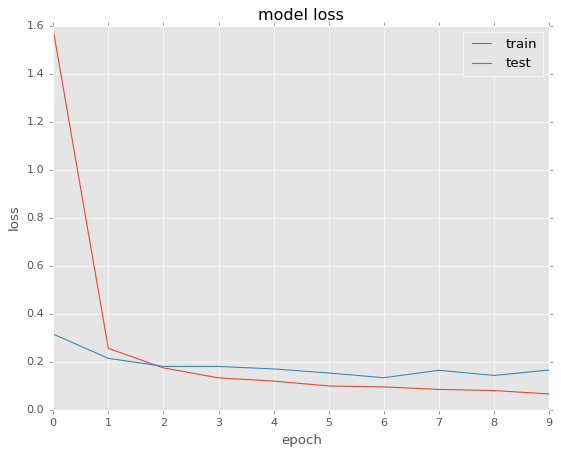

In [103]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()


### Checking for single value

In [109]:
# Reverse encoding single value and 
#tf.expand_dims(X_test_digit[0])
y_predict_single = model.predict(X_test_digit[[300]])
y_predicts_single=np.argmax(y_predict_single, axis=1) # Here we get the index of maximum value in the encoded vector
y_test_digit_eval=np.argmax(y_test_digit, axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


In [110]:
print(y_predict_single)
print('\n', y_predicts_single)


[[2.4577547e-04 6.0530102e-01 1.0152878e-02 1.8772684e-05 9.9832839e-01
  1.8700732e-07 4.4705886e-03 2.2240043e-02 6.5138098e-04 1.1148159e-04]]

 [4]


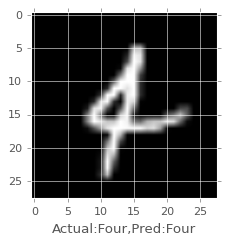

In [115]:
#Names of numbers in the dataset in order
col_names = ['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']

#Visualizing the digits
plt.figure(figsize=(3,3))
plt.imshow(X_test_digit[300].reshape(28,28), cmap='gray')
plt.xlabel("Actual:{},Pred:{}".format(col_names[np.argmax(y_test_digit[300])],col_names[y_predicts_single[0]]))
plt.show()


In [ ]:
y_test_digit_eval


array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))